## Importanto os dados de treino e teste

In [1]:
import joblib

In [ ]:
X_tr, X_te, y_tr, y_te = joblib.load('./dados_preparados.pkl')

## Importando os transformers

In [ ]:
configs = joblib.load('./transformers.pkl')
print(type(configs))

<class 'dict'>


## Imports

In [5]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate

# Treinamento dos modelos

## Regressão Logística

Treinamento do modelo com as diferentes column transformers e combinações:
- txt_word - TF-IDF para palavras, com unigramas e bigramas
- txt_word + txt_char - TF-IDF para caracteres, com trigramas a quiquigramas
- txt_word + meta - TF-IDF para palavras e metadados estilométricos
- txt_word + txt_char + meta - Todos os passos combinados

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_predict, cross_validate
'''
scoring = ["f1_macro", "accuracy", "precision_macro", "recall_macro"]
resultados = []

print("Random forest")
for nome, transformers in configs.items():
    pipe = Pipeline(
        [
            ("prep", ColumnTransformer(transformers)),
            ("rf", RandomForestClassifier(n_estimators=100, random_state=42))
        ]
    )

    # 1. Executa o cross_validate padrão para as métricas do seu relatório
    cv = cross_validate(pipe, X_tr, y_tr, cv=5, scoring=scoring)
    print(f"\n{nome}")

    linha = {"config": nome}
    for m in scoring:
        vals = cv[f"test_{m}"]
        print(f"  {m}: {vals.mean():.4f} ± {vals.std():.4f}")
        linha[f"{m}_mean"] = vals.mean()
        linha[f"{m}_std"] = vals.std()

    resultados.append(linha)

    # Matriz de confusão
    y_pred_cv = cross_val_predict(pipe, X_tr, y_tr, cv=5)

    cm = confusion_matrix(y_tr, y_pred_cv)

    fig, ax = plt.subplots(figsize=(5, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", ax=ax)
    ax.set_title(f"Matriz de Confusão: {nome}")
    plt.show()
    '''


'\nscoring = ["f1_macro", "accuracy", "precision_macro", "recall_macro"]\nresultados = []\n\nprint("Random forest")\nfor nome, transformers in configs.items():\n    pipe = Pipeline(\n        [\n            ("prep", ColumnTransformer(transformers)),\n            ("rf", RandomForestClassifier(n_estimators=100, random_state=42))\n        ]\n    )\n\n    # 1. Executa o cross_validate padrão para as métricas do seu relatório\n    cv = cross_validate(pipe, X_tr, y_tr, cv=5, scoring=scoring)\n    print(f"\n{nome}")\n\n    linha = {"config": nome}\n    for m in scoring:\n        vals = cv[f"test_{m}"]\n        print(f"  {m}: {vals.mean():.4f} ± {vals.std():.4f}")\n        linha[f"{m}_mean"] = vals.mean()\n        linha[f"{m}_std"] = vals.std()\n\n    resultados.append(linha)\n\n    # Matriz de confusão\n    y_pred_cv = cross_val_predict(pipe, X_tr, y_tr, cv=5)\n\n    cm = confusion_matrix(y_tr, y_pred_cv)\n\n    fig, ax = plt.subplots(figsize=(5, 5))\n    disp = ConfusionMatrixDisplay(confusio

              precision    recall  f1-score   support

           0     0.8926    0.9583    0.9243       720
           1     0.9550    0.8847    0.9185       720

    accuracy                         0.9215      1440
   macro avg     0.9238    0.9215    0.9214      1440
weighted avg     0.9238    0.9215    0.9214      1440



AttributeError: This 'Pipeline' has no attribute 'decision_function'

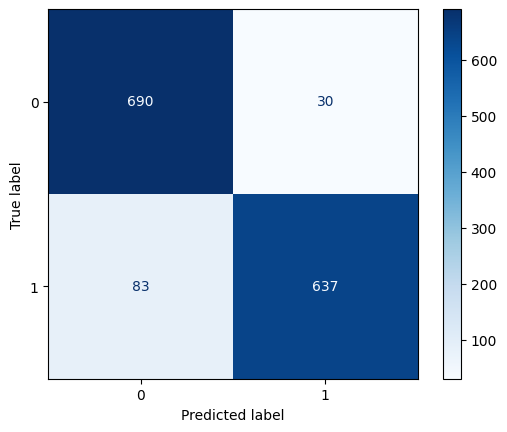

In [8]:
import numpy as np
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             roc_auc_score)

pipe_final = Pipeline([
    ("prep", ColumnTransformer(configs['word+char'])),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
])
pipe_final.fit(X_tr, y_tr)

y_pred = pipe_final.predict(X_te)
print(classification_report(y_te, y_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred, cmap="Blues")

# LinearSVC não tem predict_proba; para AUC use decision_function
print("ROC-AUC:", roc_auc_score(y_te, pipe_final.decision_function(X_te)))

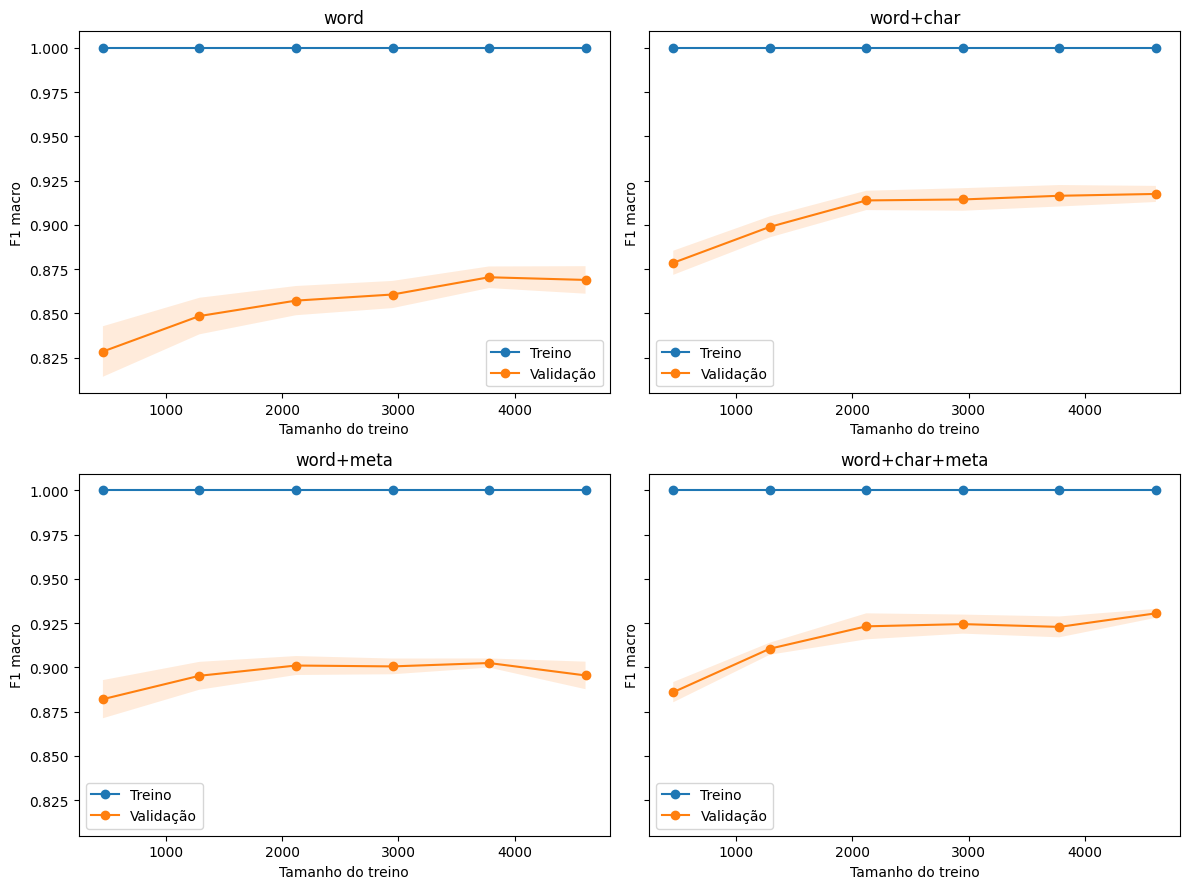

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold

cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)

for ax, (nome, transformers) in zip(axes.ravel(), configs.items()):
    pipe = Pipeline([
        ("prep", ColumnTransformer(transformers)),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_tr, y_tr,
        train_sizes=np.linspace(0.1, 1.0, 6),
        cv=cv_lc,
        scoring="f1_macro",
        n_jobs=-1,
    )

    tr_m, tr_s = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_m, va_s = val_scores.mean(axis=1), val_scores.std(axis=1)

    ax.plot(train_sizes, tr_m, "o-", label="Treino")
    ax.plot(train_sizes, va_m, "o-", label="Validação")
    ax.fill_between(train_sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15)
    ax.fill_between(train_sizes, va_m - va_s, va_m + va_s, alpha=0.15)
    ax.set_title(nome)
    ax.set_xlabel("Tamanho do treino")
    ax.set_ylabel("F1 macro")
    ax.legend()

plt.tight_layout()
plt.show()